# Day 49: Regression Diagnostics & Model Evaluation

## Topics Covered:
- Residual analysis (Residual vs X, Residual vs Predicted)
- Linearity check
- Homoscedasticity check
- Normality of residuals (Histogram & Q-Q plot)
- R-squared (Coefficient of Determination)

## Key Learnings:
- Regression assumptions must be validated before trusting inference.
- Residuals should show no clear pattern.
- Constant variance indicates homoscedasticity.
- Normal residuals support valid t-tests and confidence intervals.
- R² measures proportion of variance explained by the model.

## Insight:
Statistical significance tells whether a relationship exists.
R² tells how strong that relationship is.
Both are required for proper model evaluation.

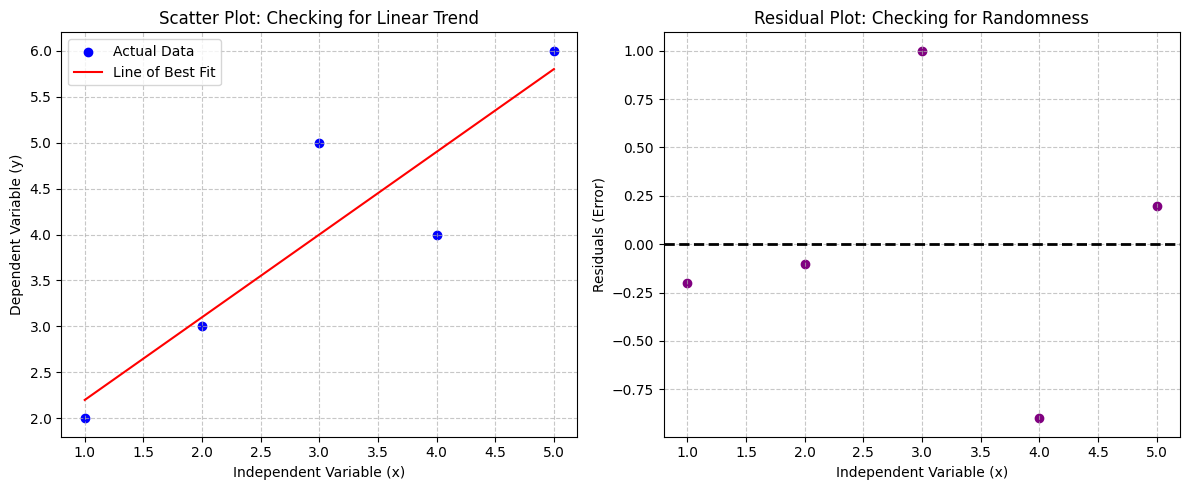

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Our dataset and core calculations from previous steps
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 4, 6])

# Calculate slope (m) and intercept (b)
x_mean, y_mean = np.mean(x), np.mean(y)
m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
b = y_mean - m * x_mean

# Calculate predictions and residuals
y_pred = m * x + b
residuals = y - y_pred

# 2. Set up the Matplotlib figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: The Scatter Plot & Line of Best Fit ---
ax1.scatter(x, y, color='blue', label='Actual Data')
ax1.plot(x, y_pred, color='red', label='Line of Best Fit')
ax1.set_title('Scatter Plot: Checking for Linear Trend')
ax1.set_xlabel('Independent Variable (x)')
ax1.set_ylabel('Dependent Variable (y)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: The Residual Plot ---
# We plot x against the residuals, and draw a horizontal reference line at zero
ax2.scatter(x, residuals, color='purple')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_title('Residual Plot: Checking for Randomness')
ax2.set_xlabel('Independent Variable (x)')
ax2.set_ylabel('Residuals (Error)')
ax2.grid(True, linestyle='--', alpha=0.7)

# Display the plots
plt.tight_layout()
plt.show()

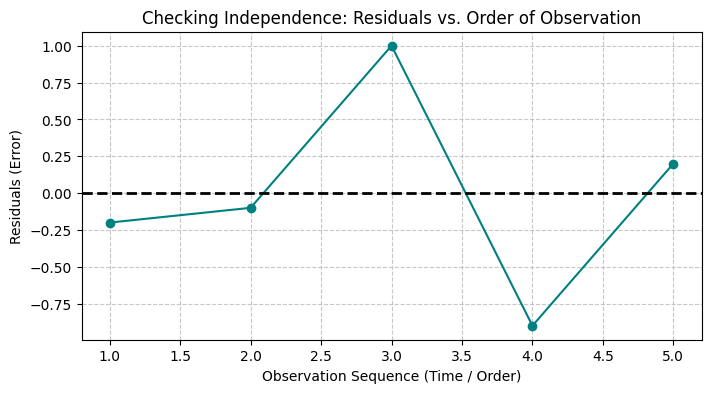

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Assuming 'residuals' is still in memory from our previous calculations
# Let's generate a simple sequence array [1, 2, 3, 4, 5] to represent the order
order_of_observations = np.arange(1, len(residuals) + 1)

# 2. Create the plot
plt.figure(figsize=(8, 4))

# We use both markers ('o') and a line ('-') to easily see if the errors are "tracking" each other
plt.plot(order_of_observations, residuals, marker='o', linestyle='-', color='teal')

# Draw our zero error reference line
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

plt.title('Checking Independence: Residuals vs. Order of Observation')
plt.xlabel('Observation Sequence (Time / Order)')
plt.ylabel('Residuals (Error)')
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Show the plot
plt.show()

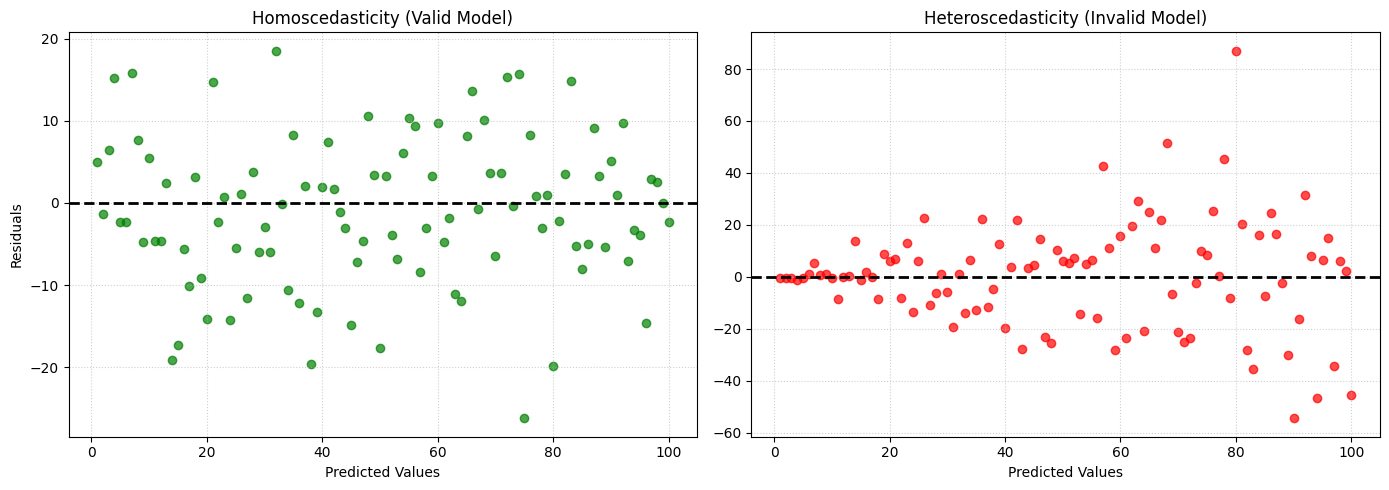

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed so the data looks the same every time you run it
np.random.seed(42)

# Generate 100 synthetic x values
x_vals = np.linspace(1, 100, 100)

# ---------------------------------------------------------
# SCENARIO 1: Homoscedasticity (The Good)
# The error's standard deviation is locked at exactly 10
# ---------------------------------------------------------
constant_errors = np.random.normal(loc=0, scale=10, size=100)
y_good = 5 * x_vals + constant_errors
# We know the true slope is 5, so we can calculate exact residuals
residuals_good = y_good - (5 * x_vals)

# ---------------------------------------------------------
# SCENARIO 2: Heteroscedasticity (The Bad)
# The error's spread gets multiplied by the x value!
# ---------------------------------------------------------
growing_errors = np.random.normal(loc=0, scale=x_vals * 0.4, size=100)
y_bad = 5 * x_vals + growing_errors
residuals_bad = y_bad - (5 * x_vals)

# --- Plotting the Comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Good (Uniform Tube)
ax1.scatter(x_vals, residuals_good, color='green', alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax1.set_title('Homoscedasticity (Valid Model)')
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot 2: The Bad (Funnel Shape)
ax2.scatter(x_vals, residuals_bad, color='red', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_title('Heteroscedasticity (Invalid Model)')
ax2.set_xlabel('Predicted Values')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

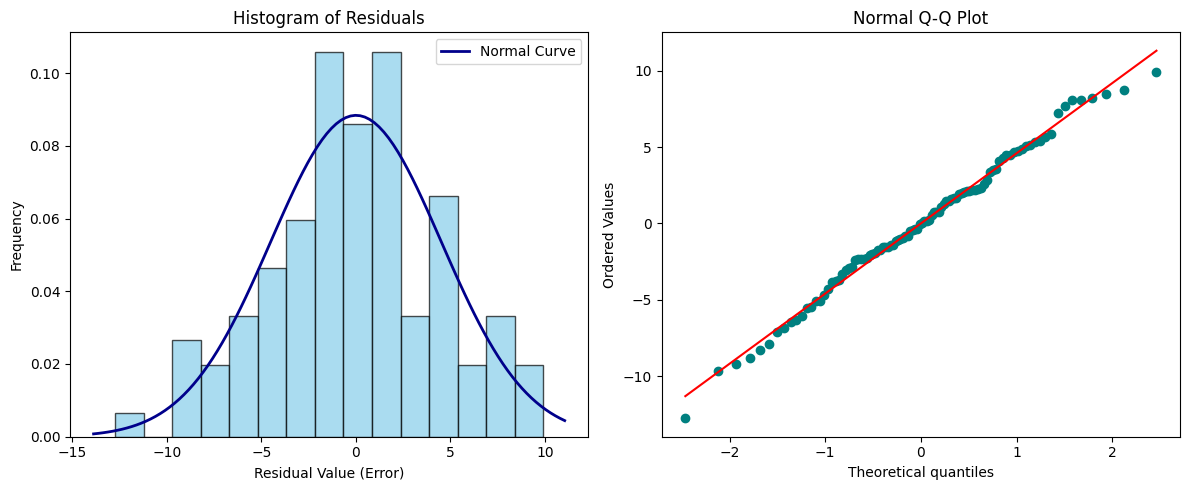

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Generate some synthetic data and calculate residuals
np.random.seed(42)
x_vals = np.linspace(1, 50, 100)
# We will add normally distributed noise to create perfect residuals
true_errors = np.random.normal(loc=0, scale=5, size=100)
y_vals = 3 * x_vals + true_errors

# Calculate slope, intercept, and residuals just like we did before
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
m = np.sum((x_vals - x_mean) * (y_vals - y_mean)) / np.sum((x_vals - x_mean)**2)
b = y_mean - m * x_mean
residuals = y_vals - (m * x_vals + b)

# 2. Set up a Matplotlib figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: The Histogram ---
# We use 'density=True' so we can overlay a smooth bell curve on top
ax1.hist(residuals, bins=15, color='skyblue', edgecolor='black', density=True, alpha=0.7)

# Overlaying a theoretical normal curve for reference
xmin, xmax = ax1.get_xlim()
x_pdf = np.linspace(xmin, xmax, 100)
y_pdf = stats.norm.pdf(x_pdf, np.mean(residuals), np.std(residuals))
ax1.plot(x_pdf, y_pdf, color='darkblue', linewidth=2, label='Normal Curve')

ax1.set_title('Histogram of Residuals')
ax1.set_xlabel('Residual Value (Error)')
ax1.set_ylabel('Frequency')
ax1.legend()

# --- Plot 2: The Q-Q Plot ---
# stats.probplot automatically plots against a theoretical normal distribution
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')
ax2.get_lines()[0].set_markerfacecolor('teal')
ax2.get_lines()[0].set_markeredgecolor('teal')

plt.tight_layout()
plt.show()

In [5]:
# 2. Calculate Residual Sum of Squares (RSS)
rss = np.sum((y - y_pred)**2)

# 3. Calculate Total Sum of Squares (TSS)
# This is just comparing the actual y values to the mean of y
tss = np.sum((y - y_mean)**2)

# 4. Calculate R-squared
r_squared = 1 - (rss / tss)

print(f"Residual Sum of Squares (RSS): {rss}")
print(f"Total Sum of Squares (TSS): {tss}")
print(f"R-squared (R²): {r_squared:.4f}")

Residual Sum of Squares (RSS): 1.9000000000000004
Total Sum of Squares (TSS): 25916.15438684328
R-squared (R²): 0.9999
